# Import Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


# Read The Dataset
## Dataset
- Name: Housing Prices
- Location: ../../02_Datasets/Generated/house_price_dataset.csv
- Used for: Regression

In [34]:
df_raw = pd.read_csv("../../../02_Datasets/Generated/house_price_dataset.csv")
df = df_raw.copy()
df.head()

,size_sqft,bedrooms,age_years,distance_city_km,price_lakhs
0,1360.0,5.0,17.0,8.17,52.95
1,1794.0,5.0,14.0,1.38,90.86
2,1630.0,1.0,8.0,7.12,67.68
3,1595.0,3.0,16.0,5.02,68.36
4,2138.0,2.0,13.0,7.22,NaN


In [35]:
# print(df.isnull().sum())

df.columns
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   size_sqft         285 non-null    object 
 1   bedrooms          285 non-null    object 
 2   age_years         285 non-null    float64
 3   distance_city_km  285 non-null    float64
 4   price_lakhs       285 non-null    float64
dtypes: float64(3), object(2)
memory usage: 11.8+ KB


,age_years,distance_city_km,price_lakhs
count,285.000000,285.000000,285.000000
mean,14.852632,10.021614,66.980386
std,8.758861,5.472977,29.224517
min,0.000000,1.090000,-8.690000
25%,7.000000,5.020000,44.940000
50%,15.000000,9.600000,67.700000
75%,22.000000,14.720000,88.690000
max,29.000000,19.940000,128.770000


# Data Clearning 

In [36]:
# df["size_sqft"].fillna(df["size_sqft"].mean(),inplace=True)
# df["bedrooms"].fillna(df["bedrooms"].mean(),inplace=True)
# df["age_years"] = df["age_years"].fillna(df["age_years"].mean())
# df["distance_city_km"] = df["distance_city_km"].fillna(df["distance_city_km"].mean())
# df["price_lakhs"] = df["price_lakhs"].fillna(df["price_lakhs"].mean)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   size_sqft         285 non-null    object 
 1   bedrooms          285 non-null    object 
 2   age_years         285 non-null    float64
 3   distance_city_km  285 non-null    float64
 4   price_lakhs       285 non-null    float64
dtypes: float64(3), object(2)
memory usage: 11.8+ KB


In [39]:
df.dropna(inplace=True)

# Linear Regression Model - Distance Vs Price (Single Features)

In [101]:
from sklearn.linear_model import LinearRegression 

In [72]:
X = np.array(df["distance_city_km"]).reshape(-1,1)
y = np.array(df["price_lakhs"]).reshape(-1,1)

# Converting In Array &  Reshape the Data in 2D


# Plotting The Graph Of X , y


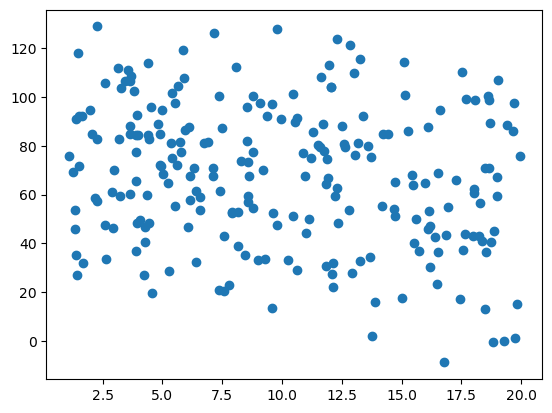

In [73]:
plt.scatter(X,y)

Note : 

# Making a Model Here with single Feature 

In [74]:
model = LinearRegression()
model.fit(X,y)


LinearRegression()

In [99]:
X_test = np.array([[34.465],[0]])

model.predict(X_test)

array([[41.52179526],
       [78.14850867]])

# Linear Regression Model - Using All The Features 

In [113]:
df["size_sqft"] = pd.to_numeric(df["size_sqft"], errors="coerce")
df = df.dropna()
df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce") # Changing the Datatype to INT so that data can be readed as the previous datatype was object 
df = df.dropna()
X_train = df[["size_sqft", "bedrooms", "age_years", "distance_city_km"]]
y_train= df["price_lakhs"]

# Plotting Graph 

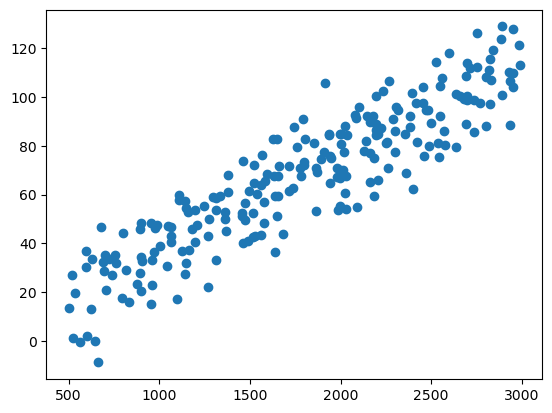

In [114]:

plt.scatter(df["size_sqft"], df["price_lakhs"])

In [115]:
model2 = LinearRegression()

In [116]:
model2.fit(X_train,y_train)

LinearRegression()

In [117]:
model2.intercept_

np.float64(3.980481413174836)

In [118]:
model2.coef_

array([ 0.03892767,  4.90295608, -0.541318  , -1.3137888 ])

# Making Test Case\Dataset 

In [122]:
X_test = pd.DataFrame( [
    [1200, 3, 5, 8],
    [1800, 4, 2, 4],
    [900, 2, 10, 12],
    [2000, 4, 1, 3],
    [1500, 3, 6, 7]
],columns=["size_sqft", "bedrooms", "age_years", "distance_city_km"])
y_test = np.array([
    70,
    95,
    50,
    110,
    75
])

# Prediction/Output

In [124]:
y_pred = model2.predict(X_test)
print(y_pred)

[52.18565727 87.32432657 27.64265398 96.96496804 64.63643008]


# Finding the Error Rate / MSE(Mean-Square-Error)

In [128]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_pred,y_test)
print(f"Mean Squared Error of the Model : {mse}")
print(f"RMSE - Root Mean Squared Error Of the Model : {np.sqrt(mse)}")

Mean Squared Error of the Model : 230.68666602660997
RMSE - Root Mean Squared Error Of the Model : 15.188372724772393
